<a href="https://colab.research.google.com/github/shagun30107-bit/csot-ml-astronomy/blob/main/WEEK2(PART1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [16]:
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT = Path("galaxy_data")
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"


!pip install -q kaggle
# Kaggle authentication
os.environ["KAGGLE_API_TOKEN"] = "KGAT_3f3d786e5f471c9718d9cc3a6e481eb9"

# Download Galaxy Zoo 2 dataset
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -p galaxy_raw

# Extract dataset
!unzip -q -o galaxy_raw/galaxy-zoo-2-images.zip -d {RAW_ROOT}

# !unzip -q -o {RAW_ROOT}/images_gz2.zip -d {IMAGES_DIR}

# Download Hart et al. labels
!wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz {LABELS_URL}
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz


Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
galaxy-zoo-2-images.zip: Skipping, found more recently modified local copy (use --force to force download)
--force to force download


In [17]:
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

mapping_head = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3)

RAW_ROOT contents: ['galaxy-zoo-2-images.zip', 'gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in galaxy_raw/images_gz2/images: 243,434


In [18]:
def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 morphology codes to a few training buckets."""
    if not gz2_class or gz2_class == "A":
        return None  # artifact / ambiguous — skip
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):
    """Symlink a balanced subset into out_root// for ImageFolder."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
                os.symlink(src.resolve(), dst)
                linked += 1
        counts[label] = linked
    return counts

PER_CLASS = 200  # balanced subset — fast on Colab; increase once the pipeline works
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)
print("Symlinked per class:", counts)
print("DATA_ROOT classes:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))

Symlinked per class: {'elliptical': 0, 'spiral': 0, 'spiral_barred': 0}
DATA_ROOT classes: ['elliptical', 'spiral', 'spiral_barred']


In [19]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

In [20]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split

dataset = ImageFolder(root=DATA_ROOT, transform=transform)

train_size = int(0.7 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_size, val_size, test_size]
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)



In [21]:
num_classes = len(train_ds.dataset.classes)
print("Classes      :", train_ds.dataset.classes)
print("Class_to_Idx :", train_ds.dataset.class_to_idx)
print("Num_Classes  :", num_classes)

Classes      : ['elliptical', 'spiral', 'spiral_barred']
Class_to_Idx : {'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}
Num_Classes  : 3


# STEP-1


In [22]:
import numpy as np

def loader_to_numpy(loader):
    xs, ys = [], []
    for images, labels in loader:               # images: (B, 3, 64, 64)
        flat = images.flatten(start_dim=1)       # (B, 12288)
        xs.append(flat.numpy())
        ys.append(labels.numpy())
    X = np.concatenate(xs, axis=0)               # (N, 12288) 2D array X of shape (n_samples, n_features)
    y = np.concatenate(ys, axis=0)               # (N,) 1D array y of labels
    return X, y

X_train, y_train = loader_to_numpy(train_loader)
X_test,  y_test  = loader_to_numpy(test_loader)
print(X_train.shape, y_train.shape)

(420, 12288) (420,)


# STEP-2 ( DummyClassifier)

In [23]:
from sklearn.dummy import DummyClassifier
model=DummyClassifier(strategy="most_frequent")
model.fit(X_train, y_train)
majority=model.score(X_test, y_test)
print(f"MAJORITY-CLASS: {majority}" )

random_guess = 1 / num_classes
print (f"RANDOM GUESS: {random_guess:.2f}" )

MAJORITY-CLASS: 0.3
RANDOM GUESS: 0.33


# STEP-3 (KNN)

In [24]:
from sklearn.neighbors import KNeighborsClassifier
model1=KNeighborsClassifier(n_neighbors=5)
model1.fit(X_train, y_train)
Score1=model1.score(X_test, y_test)
print(f"KNN accuracy: {Score1:.3f}")

KNN accuracy: 0.444


# STEP-4 (LOGISTIC REGRESSION)

In [25]:
from sklearn.linear_model import LogisticRegression
model2=LogisticRegression(max_iter=1000)
model2.fit(X_train, y_train)
Score2=model2.score(X_test, y_test)
print(f"Logistic Regression accuracy: {Score2:.3f}")


Logistic Regression accuracy: 0.422


# STEP-5 (COMPARISON TABLE)

In [26]:
results = pd.Series({
    "Random Guess": random_guess,
    "Majority Class": majority,
    "KNN (k=5)": Score1,
    "Logistic Regression": Score2
})

print(results.round(3))

print("\nbaseline to beat in WEEK3:")
print(results.idxmax(), "-", round(results.max(), 3))

Random Guess           0.333
Majority Class         0.300
KNN (k=5)              0.444
Logistic Regression    0.422
dtype: float64

baseline to beat in WEEK3:
KNN (k=5) - 0.444


# STEP-6 (stretch) - Confusion matrix

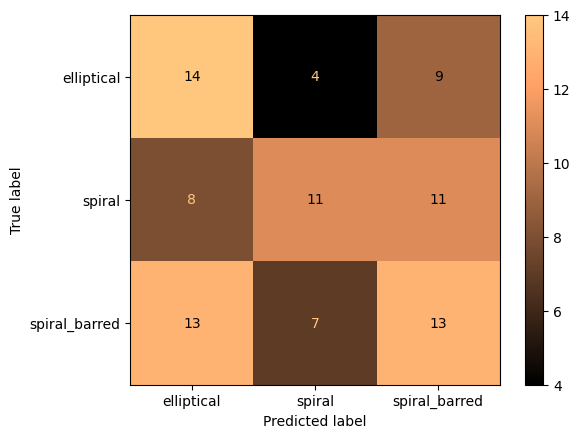

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ["elliptical", "spiral", "spiral_barred"]

cm = confusion_matrix(y_test, model2.predict(X_test))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="copper")
plt.show()

# Reflection

1.   The highest accuracy was 40% from the Majority Class baseline. KNN and Logistic Regression achieved 38.9%, so they did not improve over the majority-class baseline
2.    Because spatial relationships destroyed by flattening so that it cannot see isophote shape or arm structure.

3.  spiral & spiral_barred...both of them looks same
